# 🏥 Indian Liver Patient Prediction
**Author:**  Fola  
**Dataset:** Indian Liver Patient Dataset (ILPD) — 583 patients  
**Goal:** Build a binary classification model to predict whether a 
patient has liver disease based on blood test markers.

## Problem Statement
Liver disease is a serious medical condition. Early detection saves lives.
This project builds a machine learning model that screens patients based 
on standard blood test results and flags those at high risk for further 
medical evaluation.

## Key Decision
In a medical context, missing a sick patient (False Negative) is far more 
dangerous than wrongly flagging a healthy one (False Positive). Therefore, 
I optimized for **Recall** over accuracy throughout this project.

## 📦 Libraries
All libraries used throughout this project.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier
import pickle
import warnings
warnings.filterwarnings('ignore')

## 📂 Load Data
Loading the Indian Liver Patient Dataset and taking a first look 
at its structure, data types and missing values.

In [2]:
df = pd.read_csv('indian_liver_patient.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nTarget Distribution:")
print(df['is_patient'].value_counts())

Shape: (583, 11)

First 5 rows:


,age,gender,tot_bilirubin,direct_bilirubin,tot_proteins,albumin,ag_ratio,sgpt,sgot,alkphos,is_patient
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1



Data Types:
age                   int64
gender               object
tot_bilirubin       float64
direct_bilirubin    float64
tot_proteins          int64
albumin               int64
ag_ratio              int64
sgpt                float64
sgot                float64
alkphos             float64
is_patient            int64
dtype: object

Missing Values:
age                 0
gender              0
tot_bilirubin       0
direct_bilirubin    0
tot_proteins        0
albumin             0
ag_ratio            0
sgpt                0
sgot                0
alkphos             4
is_patient          0
dtype: int64

Target Distribution:
is_patient
1    416
2    167
Name: count, dtype: int64


## 🧹 Data Cleaning
I identified 4 issues during exploration and fix them here:
1. `is_patient` uses 1 and 2 — remapped to 1 (sick) and 0 (healthy)
2. `alkphos` has 4 missing values — filled with median (robust to outliers)
3. `gender` is text — encoded Male=1, Female=0
4. Class imbalance — 71% sick, 29% healthy (addressed later at modeling stage)

In [3]:
# Fix 1 — Remap target column
df['is_patient'] = df['is_patient'].replace({1: 1, 2: 0})

# Fix 2 — Fill missing alkphos with median
df['alkphos'] = df['alkphos'].fillna(df['alkphos'].median())

# Fix 3 — Encode gender
df['gender'] = df['gender'].replace({'Male': 1, 'Female': 0})

# Verify
print("Missing values after cleaning:")
print(df.isnull().sum())
print("\nTarget distribution after fix:")
print(df['is_patient'].value_counts())

Missing values after cleaning:
age                 0
gender              0
tot_bilirubin       0
direct_bilirubin    0
tot_proteins        0
albumin             0
ag_ratio            0
sgpt                0
sgot                0
alkphos             0
is_patient          0
dtype: int64

Target distribution after fix:
is_patient
1    416
0    167
Name: count, dtype: int64


## 🔍 Exploratory Data Analysis (EDA)
Before modeling, I explore the data to find patterns that separate 
sick patients from healthy ones. This guides my feature selection 
and modeling decisions.

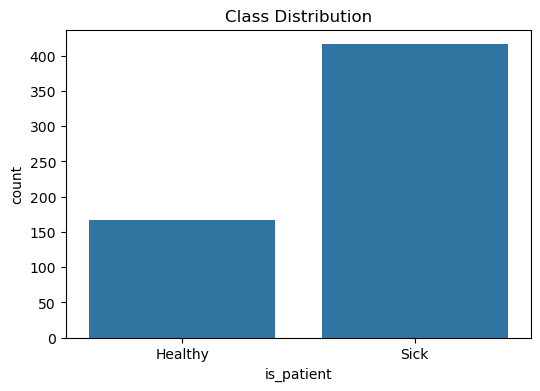

Average values by class:


,age,gender,tot_bilirubin,direct_bilirubin,tot_proteins,albumin,ag_ratio,sgpt,sgot,alkphos
is_patient,,,,,,,,,,
0,41.24,0.70,1.14,0.40,219.75,33.65,40.69,6.54,3.34,1.03
1,46.15,0.78,4.16,1.92,319.01,99.61,137.70,6.46,3.06,0.91


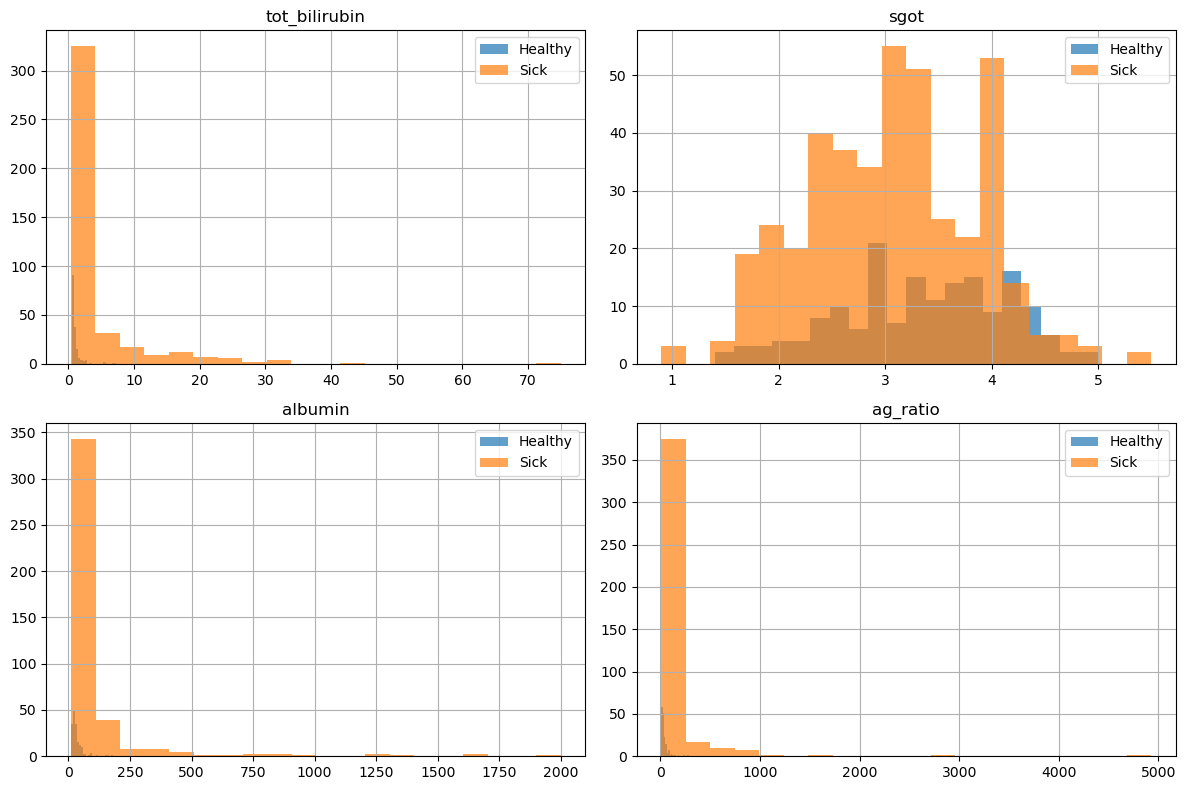

In [4]:
# Class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='is_patient', data=df)
plt.title('Class Distribution')
plt.xticks([0, 1], ['Healthy', 'Sick'])
plt.show()

# Average values by class
print("Average values by class:")
display(df.groupby('is_patient').mean().round(2))

# Feature distributions by class
plt.figure(figsize=(12, 8))
for i, col in enumerate(['tot_bilirubin', 'sgot', 'albumin', 'ag_ratio']):
    plt.subplot(2, 2, i+1)
    df.groupby('is_patient')[col].hist(alpha=0.7, bins=20)
    plt.title(col)
    plt.legend(['Healthy', 'Sick'])
plt.tight_layout()
plt.show()

## 📊 Distribution Analysis & Log Transformation
Checking feature distributions. Logistic Regression performs better 
when features are normally distributed. I identified 5 skewed features 
and applied log transformation to compress extreme values and normalize 
the distributions.

**Skewed features:** tot_bilirubin, direct_bilirubin, albumin, ag_ratio, tot_proteins

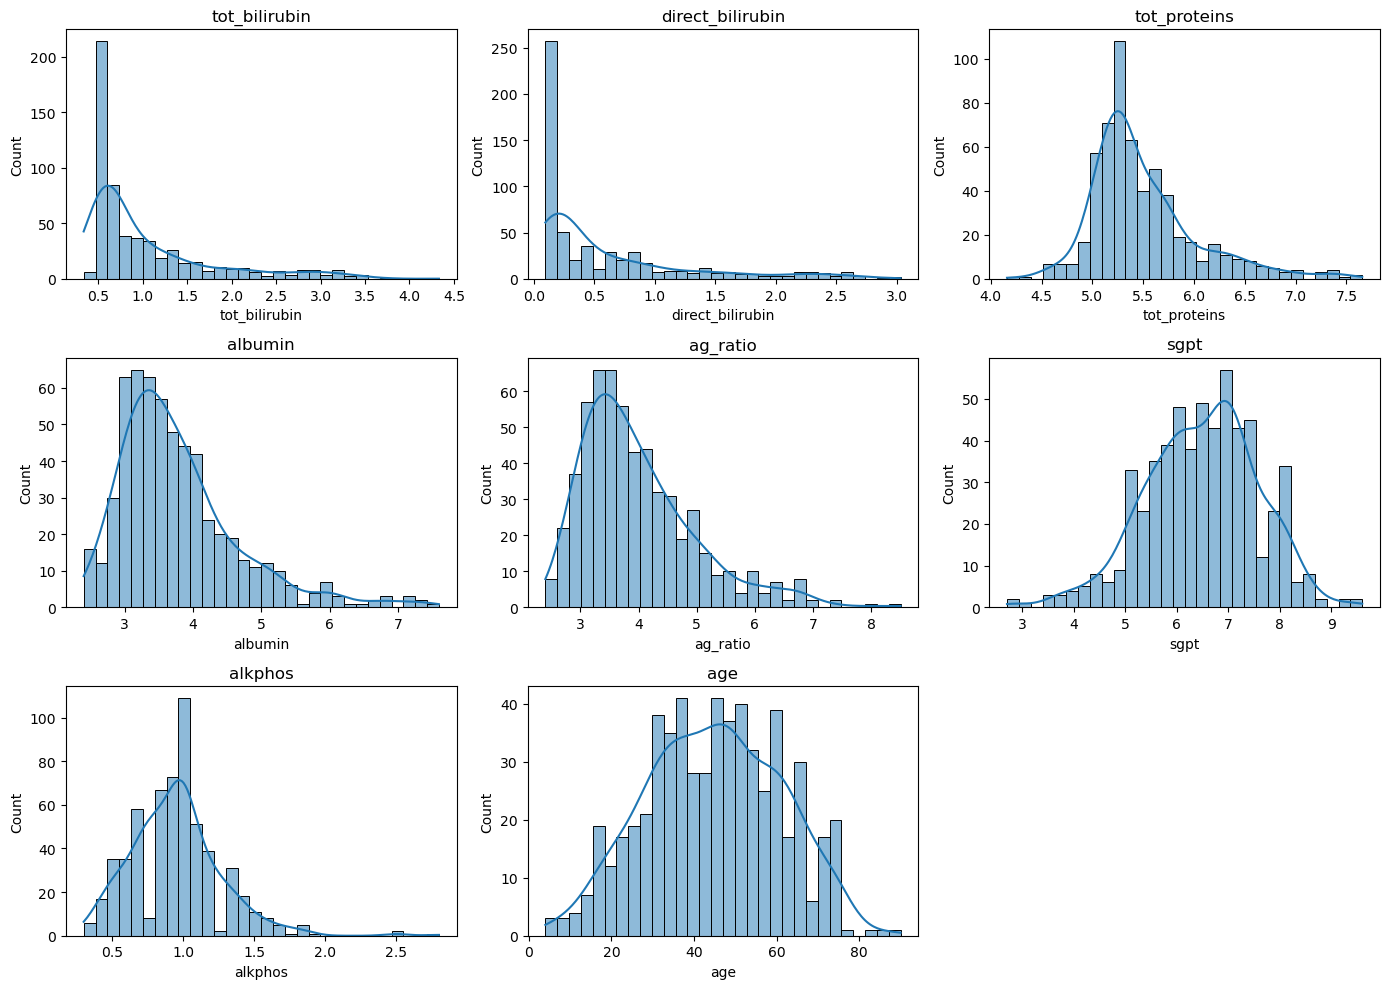

In [5]:
# Apply log transformation to skewed features
skewed_features = ['tot_bilirubin', 'direct_bilirubin', 
                   'albumin', 'ag_ratio', 'tot_proteins']

for col in skewed_features:
    df[col] = np.log1p(df[col])

# Visualize distributions after transformation
features = ['tot_bilirubin', 'direct_bilirubin', 'tot_proteins', 
            'albumin', 'ag_ratio', 'sgpt', 'alkphos', 'age']

plt.figure(figsize=(14, 10))
for i, col in enumerate(features):
    plt.subplot(3, 3, i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

## ⚙️ Preprocessing
Preparing data for modeling:
1. Remove weak features (sgot, gender) based on feature importance analysis
2. Separate features (X) from target (y)
3. Split into 80% train, 20% test
4. Scale features using StandardScaler — ensures no feature dominates due to magnitude

In [6]:
# Remove weak features and target
X = df.drop(columns=['sgot', 'gender', 'is_patient'])
y = df['is_patient']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (466, 8)
X_test shape: (117, 8)


## 🤖 Model Training & Evaluation
I tested 3 models : Logistic Regression, Random Forest, and XGBoost.
Logistic Regression performed best on our key metric: Recall for sick patients.

**Why Recall over Accuracy?**
Missing a sick patient (False Negative) is life-threatening. I optimize 
for catching as many sick patients as possible, accepting more False Positives 
as a reasonable tradeoff.

**Threshold tuning:** I lowered the decision threshold from 0.5 to 0.45 
to be more aggressive at flagging sick patients — reducing False Negatives 


=== Classification Report ===
              precision    recall  f1-score   support

           0       0.40      0.13      0.20        30
           1       0.76      0.93      0.84        87

    accuracy                           0.73       117
   macro avg       0.58      0.53      0.52       117
weighted avg       0.67      0.73      0.67       117

=== Confusion Matrix ===
[[ 4 26]
 [ 6 81]]


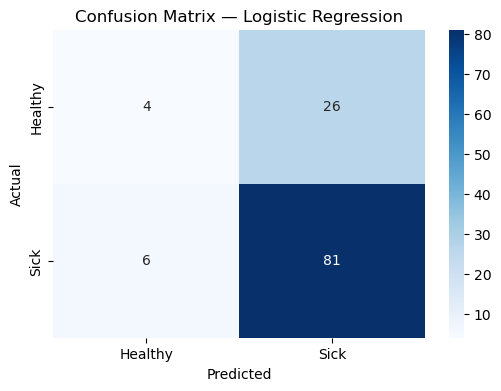

Model and scaler saved successfully.


In [7]:
# Train Logistic Regression
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

# Predict with tuned threshold
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.45).astype(int)

# Evaluate
print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

print("=== Confusion Matrix ===")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy', 'Sick'],
            yticklabels=['Healthy', 'Sick'])
plt.title('Confusion Matrix — Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Save model and scaler
with open('liver_model_v2.pkl', 'wb') as f:
    pickle.dump(model, f)
with open('scaler_v2.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model and scaler saved successfully.")

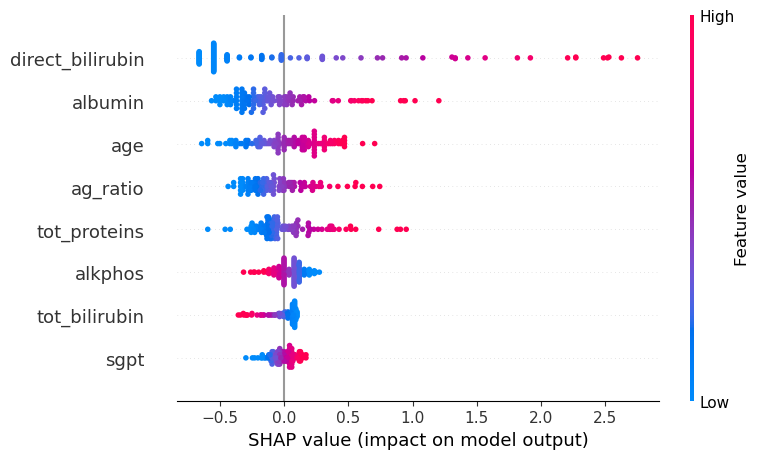

In [8]:
import shap

# Create SHAP explainer
explainer = shap.LinearExplainer(model, X_train)
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test, 
                  feature_names=['age', 'tot_bilirubin', 'direct_bilirubin',
                                 'tot_proteins', 'albumin', 'ag_ratio', 
                                 'sgpt', 'alkphos'])

## 🔬 Clinical Interpretation of SHAP Results

**Direct Bilirubin** — The strongest predictor. High direct bilirubin 
strongly pushes predictions toward liver disease. Clinically, elevated 
conjugated bilirubin signals the liver's failure to excrete waste,
a direct marker of hepatobiliary dysfunction.

**Albumin** — Contradicts clinical expectation in this dataset. 
Low albumin should indicate liver failure, but the model shows the 
opposite pattern, likely due to class imbalance and small sample size. 
This highlights the danger of trusting model outputs without clinical validation.

**AG Ratio** — Higher values push toward sick prediction. Clinically, 
a falling AG ratio reflects simultaneous albumin decline and globulin 
rise; capturing both synthetic liver failure and systemic inflammation 
in a single marker.

⚠️ **Important:** SHAP explains what the model learned from this dataset,
not universal clinical truth. Always validate ML findings against 
medical literature and expert judgment.